In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data directly from the internet (easiest while building)
df = pd.read_csv('https://corgis-edu.github.io/corgis/datasets/csv/video_games/video_games.csv')

print("✅ Success! Data loaded.")

✅ Success! Data loaded.


In [2]:
# Show shape (rows, columns)
print(df.shape)  # Expected: ~ (1212, 28)

# Show first 5 rows
df.head()

# Summary statistics for numerical columns
df.describe()

# Check data types and missing values
df.info()

# Check for duplicates
print(df.duplicated().sum())

(1212, 36)
<class 'pandas.DataFrame'>
RangeIndex: 1212 entries, 0 to 1211
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Title                          1212 non-null   str    
 1   Features.Handheld?             1212 non-null   bool   
 2   Features.Max Players           1212 non-null   int64  
 3   Features.Multiplatform?        1212 non-null   bool   
 4   Features.Online?               1212 non-null   bool   
 5   Metadata.Genres                1212 non-null   str    
 6   Metadata.Licensed?             1212 non-null   bool   
 7   Metadata.Publishers            948 non-null    str    
 8   Metadata.Sequel?               1212 non-null   bool   
 9   Metrics.Review Score           1212 non-null   int64  
 10  Metrics.Sales                  1212 non-null   float64
 11  Metrics.Used Price             1212 non-null   float64
 12  Release.Console                1212 non-null   s

In [3]:
# Handling missing values in Publishers
df['Metadata.Publishers'] = df['Metadata.Publishers'].fillna('Unknown')

In [4]:
# Feature Engineering: Extract the primary genre (first one listed)
df['Primary_Genre'] = df['Metadata.Genres'].apply(lambda x: x.split(',')[0])

In [5]:
# Set visual style
sns.set_theme(style="whitegrid")

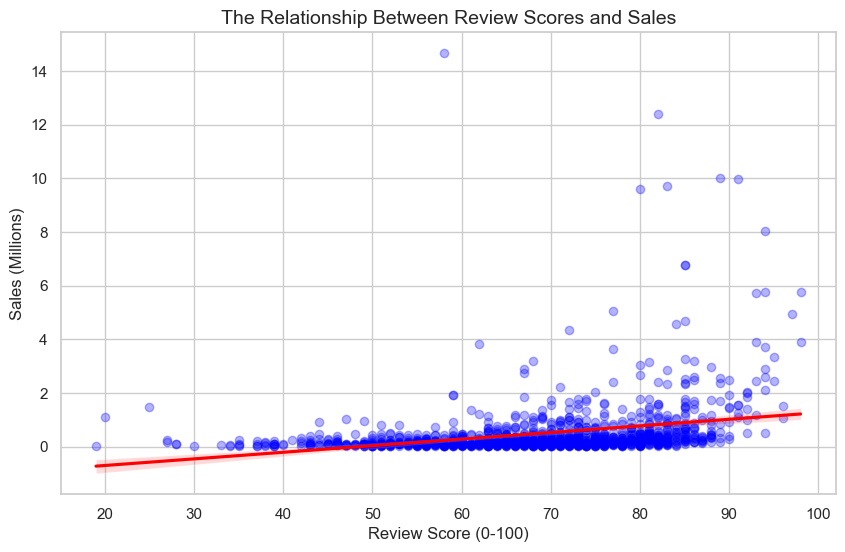

In [6]:
# --- CHAPTER 1: Does Quality Drive Sales? ---
# Columns: Metrics.Review Score, Metrics.Sales
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Metrics.Review Score', y='Metrics.Sales', 
            scatter_kws={'alpha':0.3, 'color':'blue'}, line_kws={'color':'red'})
plt.title('The Relationship Between Review Scores and Sales', fontsize=14)
plt.xlabel('Review Score (0-100)')
plt.ylabel('Sales (Millions)')
plt.savefig('1_quality_vs_sales.png')

C:\Users\aiden\AppData\Local\Temp\ipykernel_23336\1844376883.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=console_sales.index, y=console_sales.values, palette='magma')


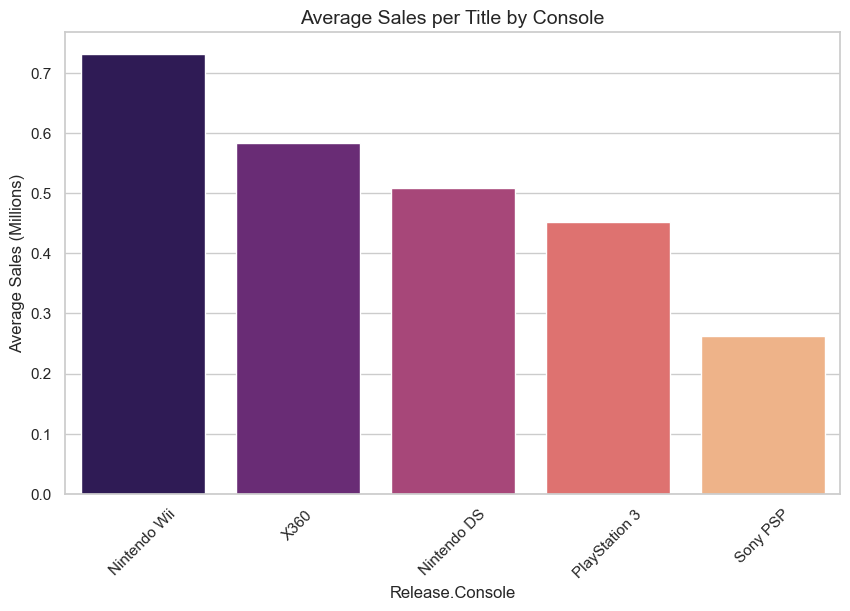

In [9]:
# --- CHAPTER 2: Platform Dominance ---
# Columns: Release.Console, Metrics.Sales
plt.figure(figsize=(10, 6))
console_sales = df.groupby('Release.Console')['Metrics.Sales'].mean().sort_values(ascending=False)
sns.barplot(x=console_sales.index, y=console_sales.values, palette='magma')
plt.title('Average Sales per Title by Console', fontsize=14)
plt.ylabel('Average Sales (Millions)')
plt.xticks(rotation=45)
plt.savefig('2_console_performance.png')

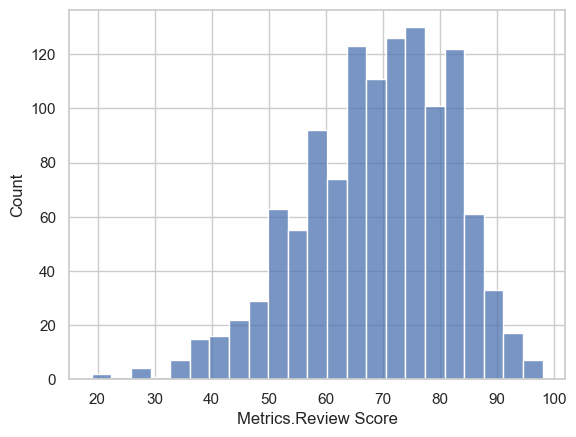

In [10]:
sns.histplot(df['Metrics.Review Score']);
plt.show()

C:\Users\aiden\AppData\Local\Temp\ipykernel_23336\994754865.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Metadata.Sequel?', y='Metrics.Sales', palette='Set2')


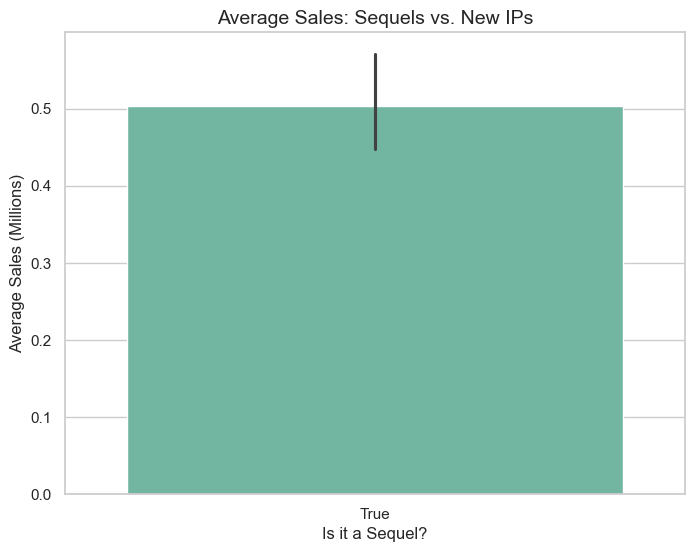

In [11]:
# --- CHAPTER 3: The "Safe Bet" - Sequels vs. New IPs ---
# Columns: Metadata.Sequel?, Metrics.Sales
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Metadata.Sequel?', y='Metrics.Sales', palette='Set2')
plt.title('Average Sales: Sequels vs. New IPs', fontsize=14)
plt.xlabel('Is it a Sequel?')
plt.ylabel('Average Sales (Millions)')
plt.savefig('3_sequel_advantage.png')

In [12]:
# --- CHAPTER 4: Genre Market Mapping ---
# Columns: Primary_Genre, Metrics.Sales, Metrics.Review Score
genre_stats = df.groupby('Primary_Genre').agg({
    'Metrics.Sales': 'mean',
    'Metrics.Review Score': 'mean'
}).reset_index()


Analysis Complete! Charts saved as PNG files.


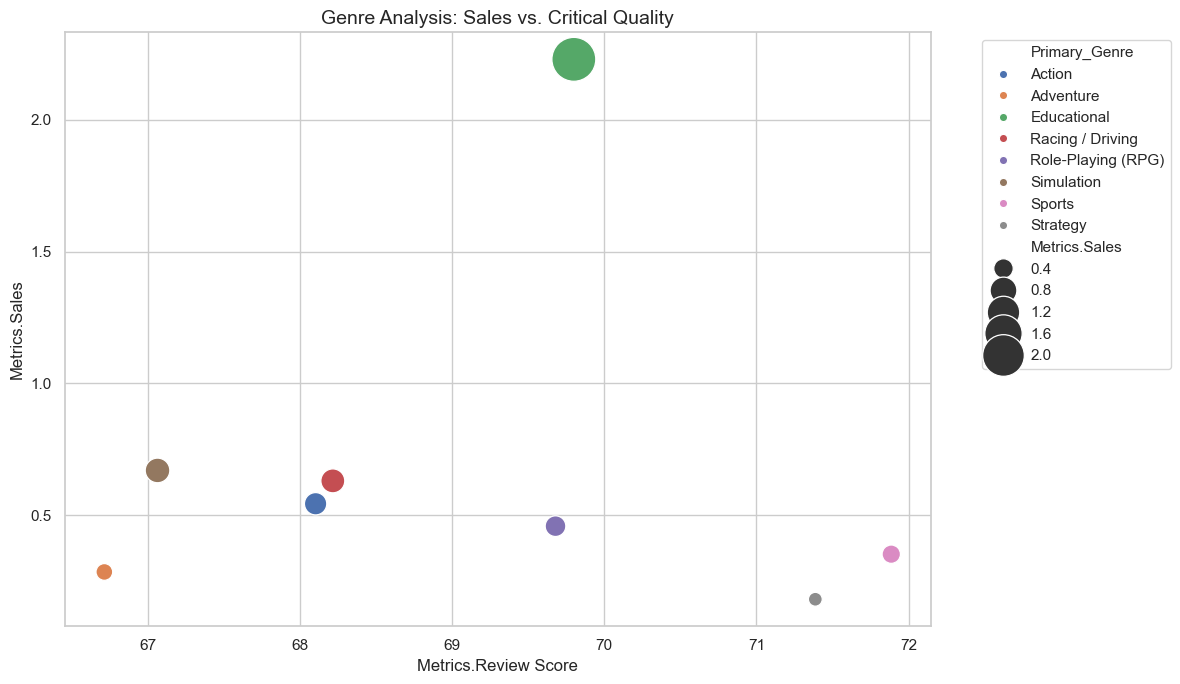

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=genre_stats, x='Metrics.Review Score', y='Metrics.Sales', 
                size='Metrics.Sales', sizes=(100, 1000), hue='Primary_Genre')
plt.title('Genre Analysis: Sales vs. Critical Quality', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('4_genre_mapping.png')

print("Analysis Complete! Charts saved as PNG files.")

In [ ]:
oh